In [48]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
load_dotenv()

True

In [49]:


llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=0.7,
    google_api_key=os.environ["GOOFLE_API_KEY"]
)

In [50]:
response = llm.invoke("meaning of water")
print(response.content)


[{'type': 'text', 'text': 'The "meaning" of water can be defined in several ways, depending on whether you are looking at it from a scientific, biological, symbolic, or philosophical perspective.\n\nHere is a breakdown of what water means across different fields:\n\n### 1. Scientific Definition\nChemically, water is a molecule made of two hydrogen atoms and one oxygen atom (**$H_2O$**). \n*   **The Universal Solvent:** It is called this because it dissolves more substances than any other liquid.\n*   **Three States:** It is the only substance on Earth that commonly exists in three states: solid (ice), liquid (water), and gas (vapor).\n*   **Unique Density:** Unlike most substances, water becomes less dense when it freezes, which is why ice floats. This allows life to survive in frozen lakes and oceans.\n\n### 2. Biological Meaning (The Source of Life)\nIn biology, water is the fundamental requirement for life. \n*   **The Medium of Life:** Every known living organism requires water to 

In [51]:
response = llm.invoke("weather forecast of patna with date time and temperature")
print(response.content)


[{'type': 'text', 'text': 'As of **Friday, May 24, 2024**, Patna is experiencing intense summer heat. Below is the weather forecast including date, time, and temperature:\n\n### **Current Status (May 24, 10:30 AM)**\n*   **Temperature:** 35°C\n*   **Condition:** Hazy Sunshine\n*   **Humidity:** 42%\n*   **Wind:** 11 km/h\n\n---\n\n### **Hourly Forecast for Today (May 24)**\n| Time | Temperature | Condition |\n| :--- | :--- | :--- |\n| 12:00 PM | 39°C | Sunny / Very Hot |\n| 02:00 PM | 41°C | Peak Heat / Clear Skies |\n| 04:00 PM | 42°C | Hazy / Heatwave conditions |\n| 06:00 PM | 38°C | Clear Sky |\n| 08:00 PM | 34°C | Clear / Warm |\n| 11:00 PM | 31°C | Clear Night |\n\n---\n\n### **7-Day Extended Forecast**\n| Date | Day | High Temp | Low Temp | Condition |\n| :--- | :--- | :--- | :--- | :--- |\n| **May 24** | Friday | 42°C | 28°C | Hazy & Hot |\n| **May 25** | Saturday | 43°C | 29°C | Severe Heat |\n| **May 26** | Sunday | 43°C | 29°C | Sunny / Heatwave |\n| **May 27** | Monday | 44

## First State Graph

### Step-1 Define The Schema

In [52]:
from typing import TypedDict

class graph_schema(TypedDict):
    name:str
    message : str


###  Create The Node Functions

In [53]:
def welcome(state : graph_schema) -> graph_schema:
    curr_name = state['name']
    curr_message = state['message']
    response = llm.invoke(f"My name is {curr_name} {curr_message}").content

    state['message'] = f"your message was {curr_message}.Here is my Response :{response}"
    return state

In [54]:
from langgraph.graph import StateGraph,START,END
graph = StateGraph(graph_schema)

graph.add_node("welcome",welcome)
graph.add_edge(START,"welcome")
graph.add_edge("welcome",END)

### step 4 compile the Graph

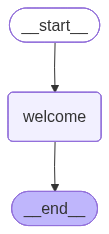

In [55]:
from IPython.display import  Image,display
first_graph = graph.compile()
Image(first_graph.get_graph().draw_mermaid_png())

### Step-5 Run The GRaph

In [56]:
first_graph.invoke({"name" : "Adarsh","message":"Hii How are YOU?"})

{'name': 'Adarsh',
 'message': 'your message was Hii How are YOU?.Here is my Response :[{\'type\': \'text\', \'text\': "Hello, Adarsh! It\'s nice to meet you. I\'m doing great, thank you for asking! \\n\\nHow are you doing today? Is there anything I can help you with?", \'extras\': {\'signature\': \'EtgFCtUFAQw51sf6yl534MHM+pUJFiGlEqpmTjY/ETxKwQ1Srp1NAVWJ3VeAL7wzE30kvl0AfyTenKPw+3yKimnTDrUqQF0ML04Fp2x1MzEqSqm62AfwXmNu86bvP8EgO5LmdnrDDbU8Y3ewsDrrQxp+bTfaNbMV2xrNb8rZuWrgTL/7a3YtsLLSXCGZXZveqjhk390EMUTo4kkjaIkLjFlKPBfkgAhoxMeZ/AWnLlscWh2jKis/1BsV7lep/lpZZNPoYYacPbkemKfmTy82vElzHbjwuEpu1Ter+SqrU4/EbQgeIkjq7+efDxBZDaOtRBD8DRtdVRhYsH3azl9Gk5PelBtUQ1t/I/nindsfR98q2Mno8Dk+s0HQu4cqZSlRzbi2GmSpQgDbXusqbsLK2+50DHCy63DijzITNUddrwhb+XqXOXr+t3HydAU9ElT2XvLRjmflAY44/eA0t5FMeg885RH3J/e2g+ChFmjHWu62QM8fkbYrkC2psgKFYPYLx66GgD2mLAi1n2m8GaCyLHsZxo7saoNaC5IUiwF4+vfIEzdRJd80PfZph/Ly/t9haAM7WNrVbZ2tRIAU/5cr74gwp5hdJwJWnTvEIOrKWhV4pQFW5QKr3A58cBqe3jwdwCxbw1ZOL2TOqJbReVr4izAjsW3qtRJ6SCL1ROJW5S5b0CE/2+dJk/hTO3H